# Імпорт бібліотек

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.externals.array_api_compat import size
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import r2_score

# Завантаження даних

In [99]:
df = pd.read_csv("cars.csv")
print(df.head())

   year  engine_volume  mileage  horsepower      price
0  2006            2.6       37         325  353978.54
1  2019            2.3      211         291  277053.49
2  2014            3.4       48         295  323868.68
3  2010            2.0      282         122   81676.45
4  2007            1.3      240         349  299506.03


# Теплова карта кореляції

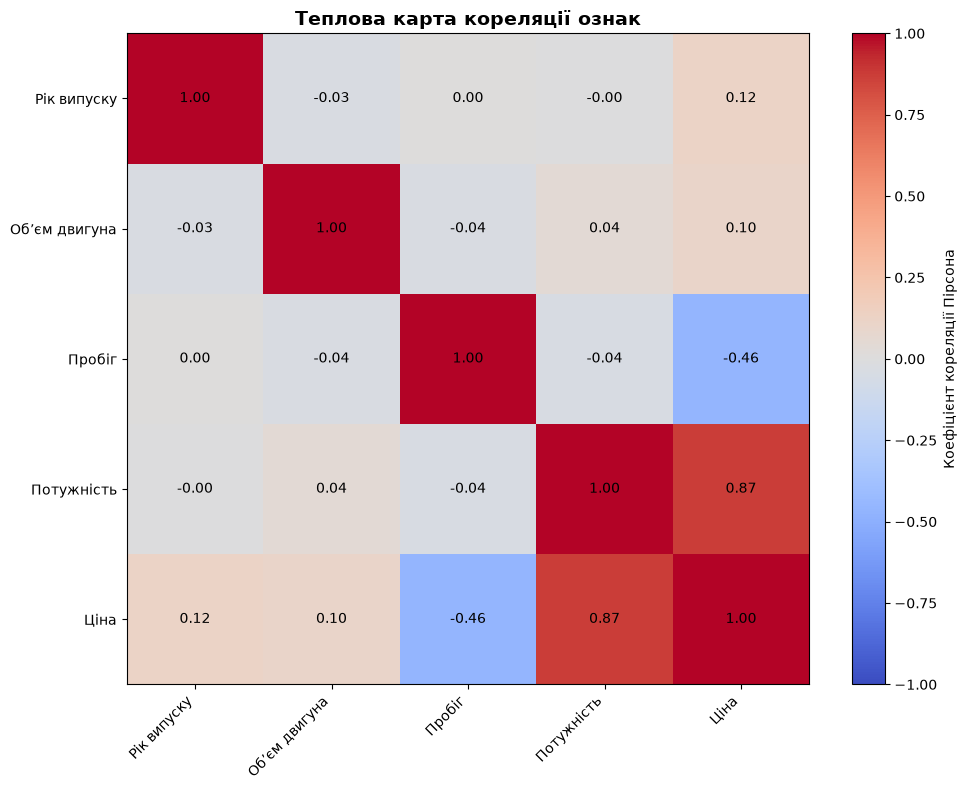

In [100]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Коефіцієнт кореляції Пірсона')
feature_labels = {'year': 'Рік випуску', 'engine_volume': 'Обʼєм двигуна', 'mileage': 'Пробіг', 'horsepower': 'Потужність', 'price': 'Ціна'}
plt.xticks(range(len(df.columns)), [feature_labels[col] for col in df.columns], rotation=45, ha='right')
plt.yticks(range(len(df.columns)), [feature_labels[col] for col in df.columns])
plt.title('Теплова карта кореляції ознак', fontsize=14, fontweight='bold')

# Add correlation values to heatmap
for i in range(len(df.columns)):
    for j in range(len(df.columns)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()


# Підготовка даних

In [101]:
x = df[['year', 'engine_volume', 'mileage', 'horsepower']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print("\nTraining set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])


Training set size: 240
Test set size: 60


# Тренування моделі

In [102]:

model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[1371.84,8542.67,-395.16, 809.78]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['year','engine_volume','mileage','horsepower']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.679e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


# Прогнозування

In [103]:
y_pred = model.predict(X_test)

# Розрахунок MAPE

In [104]:

# Calculate percentage error (MAPE)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"Процент помилки: {mape:.2f}%")

Процент помилки: 8.67%


# Графік "Справжня vs Прогнозована ціна"

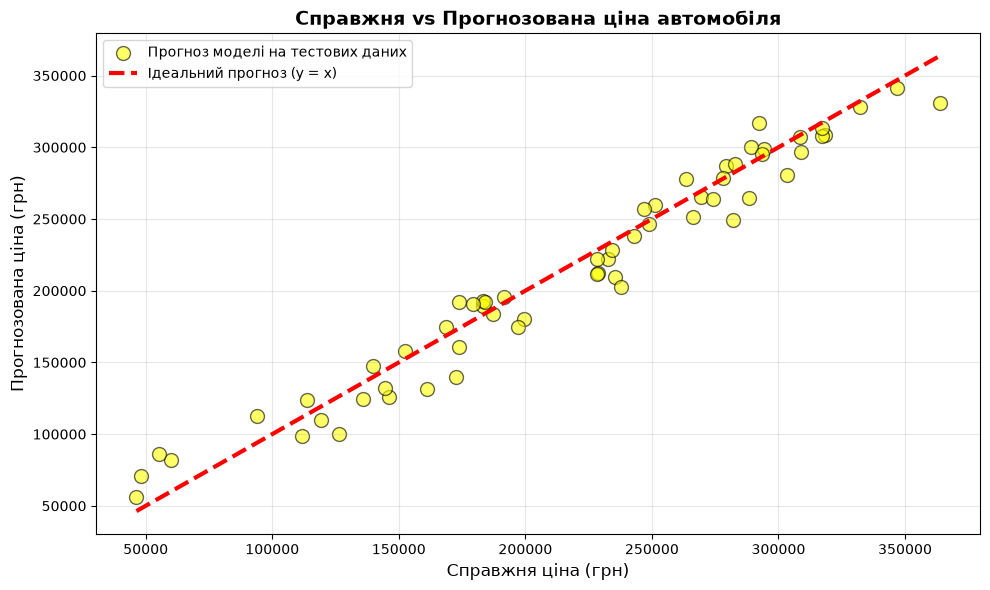

R² Score: 0.9578 - показник того, наскільки добре модель пояснює варіацію в даних. 
Значення R² близьке до 1 вказує на хорошу відповідність моделі даним.


In [105]:

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='yellow', edgecolors='black', label='Прогноз моделі на тестових даних', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Ідеальний прогноз (y = x)')
plt.xlabel('Справжня ціна (грн)', fontsize=12)
plt.ylabel('Прогнозована ціна (грн)', fontsize=12)
plt.title('Справжня vs Прогнозована ціна автомобіля', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f} - показник того, наскільки добре модель пояснює варіацію в даних. ")
print("Значення R² близьке до 1 вказує на хорошу відповідність моделі даним.")

# Коефіцієнти моделі

In [106]:
print("\nModel coefficients:")
for feature, coef in zip(x.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


Model coefficients:
year: 1371.8445
engine_volume: 8542.6656
mileage: -395.1599
horsepower: 809.7814
Intercept: -2679136.1454


# Біваріантний графік

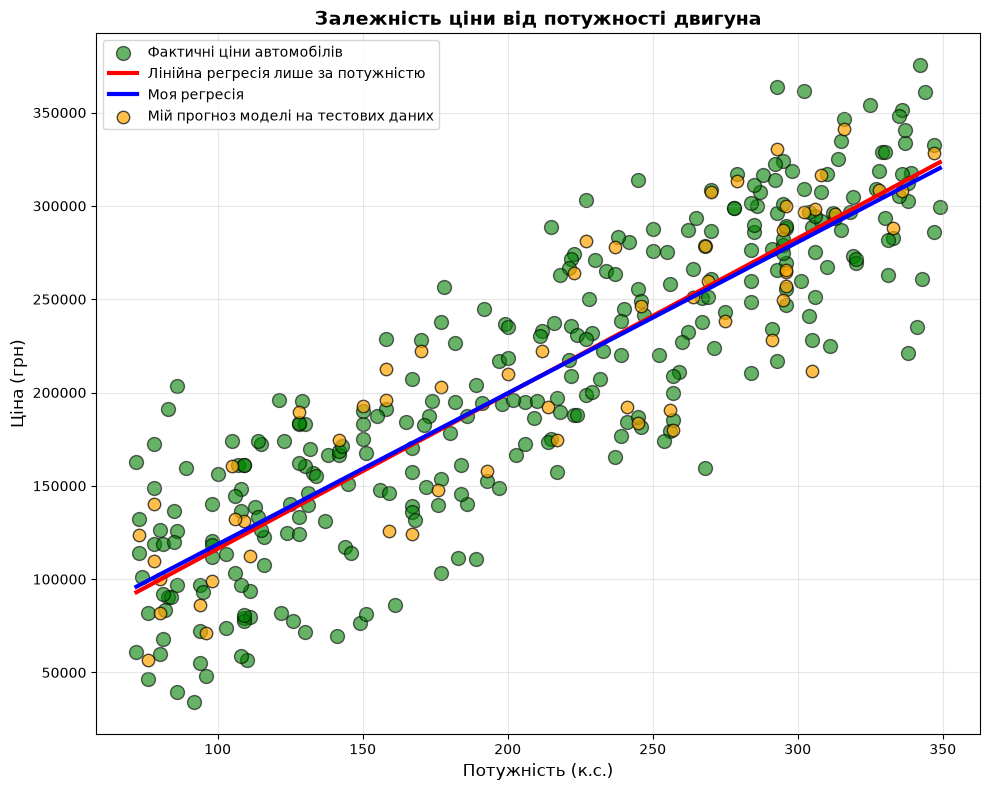


Регресія ціни за потужністю:
Коефіцієнт: 831.82
Вільний член: 33098.89
Рівняння: Ціна = 831.82 * Потужність + 33098.89


In [107]:
# Bivariate chart: Horsepower vs Price with regression line
plt.figure(figsize=(10, 8))
plt.scatter(df['horsepower'], df['price'], alpha=0.6, color='green', edgecolors='black', label='Фактичні ціни автомобілів', s=100)

horsepower_reshaped = df['horsepower'].values.reshape(-1, 1)
simple_model = LinearRegression()
simple_model.fit(horsepower_reshaped, df['price'])

# Generate the horsepower-only regression line
horsepower_range = np.linspace(df['horsepower'].min(), df['horsepower'].max(), 100).reshape(-1, 1)
price_pred = simple_model.predict(horsepower_range)
plt.plot(horsepower_range, price_pred, 'r-', lw=3, label='Лінійна регресія лише за потужністю')

# Predict across horsepower while holding other features at their training medians
model_features = pd.DataFrame(
    np.repeat(X_train.median().to_numpy()[None, :], len(horsepower_range), axis=0),
    columns=X_train.columns,
)
model_features['horsepower'] = horsepower_range.ravel()
my_price_pred = model.predict(model_features)
plt.plot(horsepower_range, my_price_pred, color='blue', lw=3, label='Моя регресія')
plt.scatter(X_test['horsepower'], y_pred, alpha=0.7, color='orange', edgecolors='black', label='Мій прогноз моделі на тестових даних', s=80)

plt.xlabel('Потужність (к.с.)', fontsize=12)
plt.ylabel('Ціна (грн)', fontsize=12)
plt.title('Залежність ціни від потужності двигуна', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nРегресія ціни за потужністю:")
print(f"Коефіцієнт: {simple_model.coef_[0]:.2f}")
print(f"Вільний член: {simple_model.intercept_:.2f}")
print(f"Рівняння: Ціна = {simple_model.coef_[0]:.2f} * Потужність + {simple_model.intercept_:.2f}")


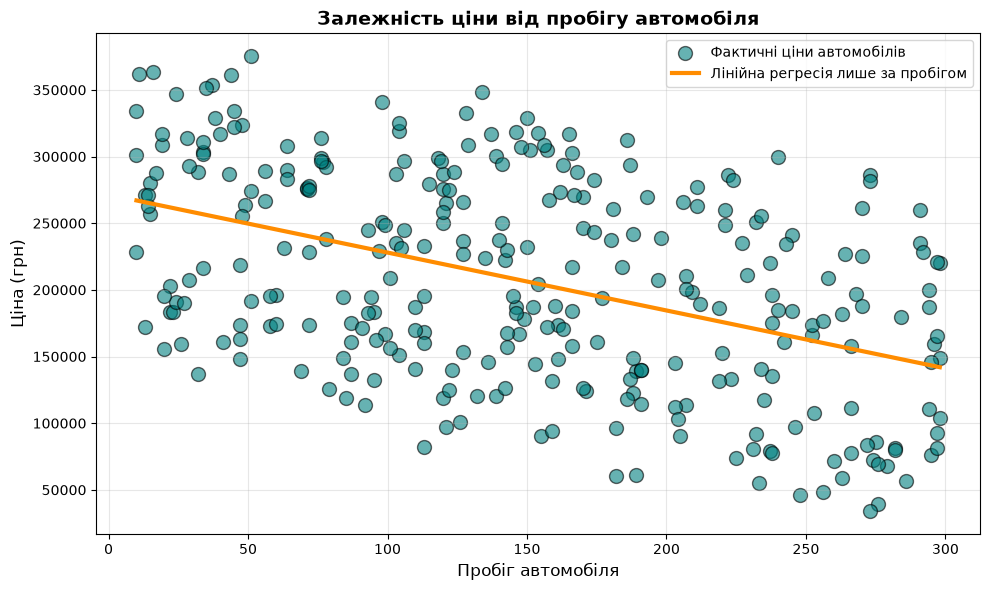


Регресія ціни за пробігом:
Коефіцієнт: -434.38
Вільний член: 271428.50
Рівняння: Ціна = -434.38 * Пробіг + 271428.50


In [108]:
# Bivariate chart: Mileage vs Price with regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['mileage'], df['price'], alpha=0.6, color='teal', edgecolors='black', label='Фактичні ціни автомобілів', s=100)

mileage_reshaped = df['mileage'].values.reshape(-1, 1)
simple_model = LinearRegression()
simple_model.fit(mileage_reshaped, df['price'])

# Generate the mileage-only regression line
mileage_range = np.linspace(df['mileage'].min(), df['mileage'].max(), 100).reshape(-1, 1)
price_pred = simple_model.predict(mileage_range)
plt.plot(mileage_range, price_pred, color='darkorange', lw=3, label='Лінійна регресія лише за пробігом')

plt.xlabel('Пробіг автомобіля', fontsize=12)
plt.ylabel('Ціна (грн)', fontsize=12)
plt.title('Залежність ціни від пробігу автомобіля', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nРегресія ціни за пробігом:")
print(f"Коефіцієнт: {simple_model.coef_[0]:.2f}")
print(f"Вільний член: {simple_model.intercept_:.2f}")
print(f"Рівняння: Ціна = {simple_model.coef_[0]:.2f} * Пробіг + {simple_model.intercept_:.2f}")
